In [2]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

In [3]:
TABLES_DIR = Path("reports/tables")
FIGURES_DIR = Path("reports/figures")

TABLES_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

In [4]:
df = pd.read_csv("saudi_data_jobs_cleaned.csv")

df.head()

,job_id,job_title,company,city,role_type,experience_level,skills,tools,source,job_link,date_collected,notes,city_cleaned,experience_category,role_category
0,1,Data Analyst,ALESAYI HOLDING,Jeddah,Data Analyst,Entry level / 3 years,"customer data analysis, operational performanc...","Excel, PowerPoint, dashboards",LinkedIn,https://sa.linkedin.com/jobs/view/data-analyst...,2026-06-30,Customer experience data analyst role in autom...,Jeddah,Entry Level,Data Analysis
1,2,Geological Data Scientist,Maaden Barrick Copper Company,Mahd Adh Dhahab,Data Scientist,Entry level / 2-5 years,"geological data management, data quality manag...","SQL, Python, Power BI, Tableau, relational dat...",LinkedIn,https://sa.linkedin.com/jobs/view/geological-d...,2026-06-30,Mining sector data science role. Focuses on ge...,Mahd Adh Dhahab,Entry Level,Data Science
2,3,Data Analyst,PrimeGate for Communications and IT,Riyadh,Data Analyst,Entry level,"data analysis, insights generation, dashboardi...","SQL, Power BI, Tableau, Looker, Excel, Python,...",LinkedIn,https://sa.linkedin.com/jobs/view/data-analyst...,2026-06-30,Entry-level data analyst role for Madinaty Sup...,Riyadh,Entry Level,Data Analysis
3,4,Analyst Pricing Analytics and Insights,Schneider Electric,Saudi Arabia,Business / Pricing Analytics,Entry level,"pricing analytics, data analysis, data interpr...","data visualization, dashboards, charts, reports",LinkedIn,https://sa.linkedin.com/jobs/view/analyst-pric...,2026-06-30,Entry-level pricing analytics role. Focuses on...,Not specified,Entry Level,Business / Financial Analytics
4,5,Power BI Developer,Acuative Middle East,Jeddah,BI / Power BI Developer,Mid-level,"Power BI dashboard development, business intel...","Power BI Desktop, Power BI Service, DAX, Power...",LinkedIn,https://sa.linkedin.com/jobs/view/power-bi-dev...,2026-06-30,Mid-level Power BI Developer role in Jeddah. F...,Jeddah,Not Specified,BI


In [5]:
df["tools"].head()

,tools
0,"Excel, PowerPoint, dashboards"
1,"SQL, Python, Power BI, Tableau, relational dat..."
2,"SQL, Power BI, Tableau, Looker, Excel, Python,..."
3,"data visualization, dashboards, charts, reports"
4,"Power BI Desktop, Power BI Service, DAX, Power..."


In [6]:
tools_df = df[["job_id", "tools"]].copy()

tools_df.head()

,job_id,tools
0,1,"Excel, PowerPoint, dashboards"
1,2,"SQL, Python, Power BI, Tableau, relational dat..."
2,3,"SQL, Power BI, Tableau, Looker, Excel, Python,..."
3,4,"data visualization, dashboards, charts, reports"
4,5,"Power BI Desktop, Power BI Service, DAX, Power..."


In [7]:
tools_df["tools"] = tools_df["tools"].fillna("")

In [8]:
tools_df["tools"] = tools_df["tools"].str.split(",")

In [9]:
tools_df = tools_df.explode("tools")

tools_df.head()

,job_id,tools
0,1,Excel
0,1,PowerPoint
0,1,dashboards
1,2,SQL
1,2,Python


In [10]:
tools_df["tools"] = (
    tools_df["tools"]
    .str.strip()
    .str.lower()
)

In [11]:
tools_df = tools_df[
    tools_df["tools"] != ""
]

In [12]:
tool_mapping = {

    "powerbi": "power bi",

    "power bi desktop": "power bi",

    "ms excel": "excel",

    "microsoft excel": "excel",

    "py": "python",

    "sql server": "sql"
}


tools_df["tools"] = (
    tools_df["tools"]
    .replace(tool_mapping)
)

In [13]:
tools_unique = tools_df.drop_duplicates(
    subset=["job_id", "tools"]
)

tools_unique.head()

,job_id,tools
0,1,excel
0,1,powerpoint
0,1,dashboards
1,2,sql
1,2,python


In [14]:
top_tools = (
    tools_unique["tools"]
    .value_counts()
    .reset_index()
)


top_tools.columns = [
    "Tool",
    "Number_of_jobs"
]


top_tools.head(15)

,Tool,Number_of_jobs
0,sql,24
1,excel,18
2,python,18
3,power bi,17
4,tableau,14
5,dashboards,14
6,reporting tools,7
7,pytorch,5
8,bi tools,5
9,r,5


In [15]:
top_tools.to_csv(
    TABLES_DIR / "top_tools.csv",
    index=False
)

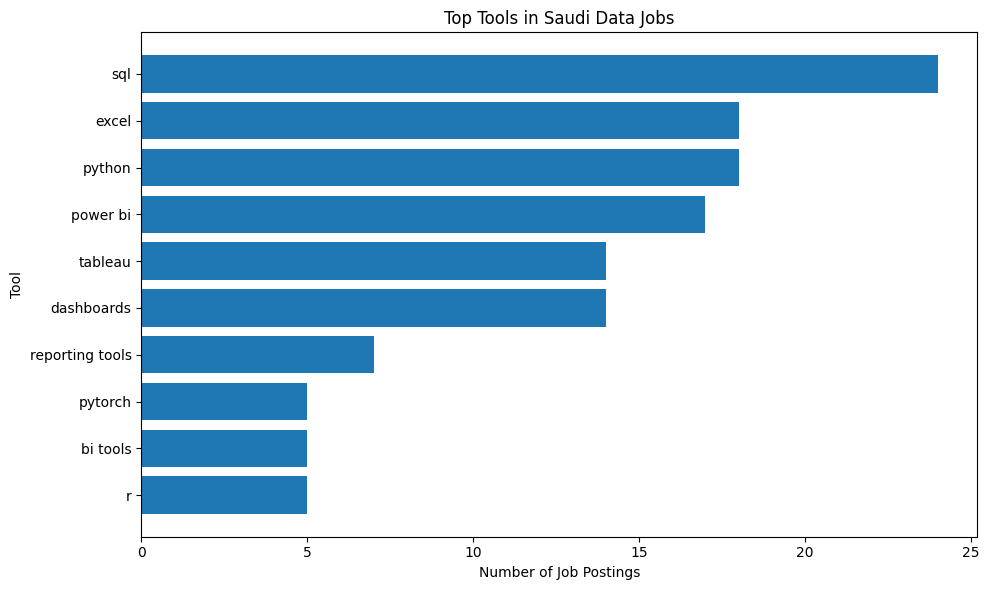

In [16]:
top10_tools = top_tools.head(10)


plt.figure(figsize=(10,6))


plt.barh(
    top10_tools["Tool"],
    top10_tools["Number_of_jobs"]
)


plt.xlabel(
    "Number of Job Postings"
)


plt.ylabel(
    "Tool"
)


plt.title(
    "Top Tools in Saudi Data Jobs"
)


plt.gca().invert_yaxis()


plt.tight_layout()


plt.savefig(
    FIGURES_DIR / "top_tools.png",
    dpi=300,
    bbox_inches="tight"
)


plt.show()

In [17]:
role_tools_analysis = tools_unique.merge(
    df[["job_id", "role_category"]],
    on="job_id",
    how="left"
)

In [18]:
tools_by_role = pd.crosstab(
    role_tools_analysis["tools"],
    role_tools_analysis["role_category"]
)


tools_by_role.head()

role_category,AI,BI,Business / Financial Analytics,Data Analysis,Data Science,Fraud Analytics,Governance,Internship / Training,Marketing Analytics,Other,Performance Analytics,Product Analytics,Research Analytics
tools,,,,,,,,,,,,,
acquire,0,0,0,0,1,0,0,0,0,0,0,0,0
ai frameworks,1,0,0,0,0,0,0,0,0,0,0,0,0
ai tools,0,0,0,0,0,0,0,0,0,0,1,0,0
ai training platforms,1,0,0,0,0,0,0,0,0,0,0,0,0
airflow,1,0,0,0,0,0,0,0,0,0,0,0,0


In [19]:
tools_by_role.to_csv(
    TABLES_DIR / "tools_by_role.csv"
)

In [20]:
import seaborn as sns

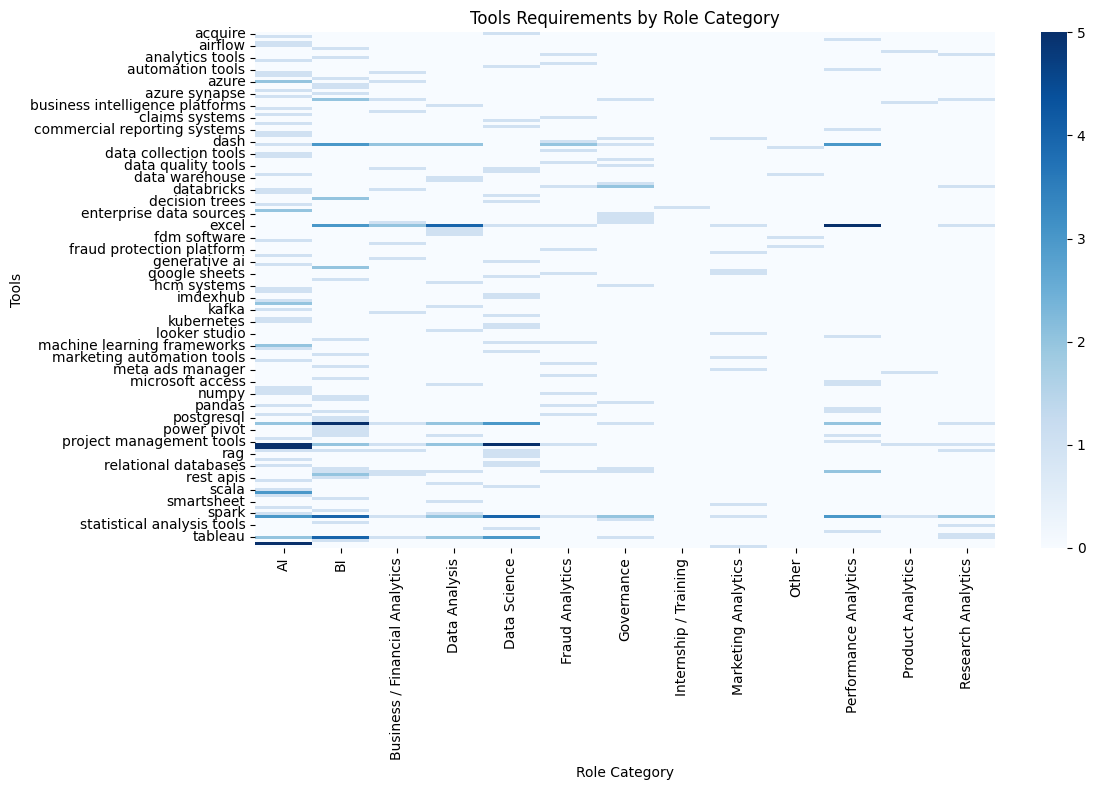

In [21]:
plt.figure(figsize=(12,8))


sns.heatmap(
    tools_by_role,
    cmap="Blues"
)


plt.title(
    "Tools Requirements by Role Category"
)


plt.xlabel(
    "Role Category"
)


plt.ylabel(
    "Tools"
)


plt.tight_layout()


plt.savefig(
    FIGURES_DIR / "tools_by_role_heatmap.png",
    dpi=300,
    bbox_inches="tight"
)


plt.show()

## Day 23 Findings

The tools analysis identified the most frequently used tools in Saudi data-related job postings.

The results show the importance of tools related to programming, data analysis, reporting, and business intelligence.

Comparing tools across role categories helps understand how tool requirements differ between Data Analysis, BI, Data Science, and other data-related career paths.

These findings will support the development of the readiness roadmap and Power BI dashboard.